# ADEF

Adaptive Evidential Fusion (ADEF) with Co-Attention

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import torchvision.transforms as transforms
import torchvision.models as models
from transformers import RobertaTokenizer, RobertaModel

from PIL import Image
import pandas as pd
import numpy as np
import os
import warnings
import random
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

# ============================================================
# REPRODUCIBILITY
# ============================================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
print("\u2705 Imports loaded & seed set.")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")


C:\Users\Residensi ADW\AppData\Roaming\Python\Python310\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Imports loaded & seed set.
PyTorch version: 2.5.1
CUDA available: True
GPU: NVIDIA GeForce RTX 3060


In [2]:
# ============================================================
# CONFIGURATION (single source of truth for ALL hyperparameters)
# ============================================================

class CFG:

    # =========================
    # PATH
    # =========================
    ROOT_DIR = r"D:/MVSA_SINGLE"
    DATA_DIR = r"D:/MVSA_SINGLE/data"
    LABEL_PATH = r"D:/MVSA_SINGLE/labelResultAllFinal.txt"

    # =========================
    # DEVICE
    # =========================
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

    # =========================
    # DATA
    # =========================
    # True  -> drop contradictory text-image pairs (identical to the 4
    #          baseline notebooks, fair comparison).
    # False -> keep them (ablation: gives ADEF Route B real conflict cases).
    FILTER_CONFLICT_PAIRS = True

    # =========================
    # OPTIMIZATION HYPERPARAMETERS
    # =========================
    BATCH_SIZE = 16
    EPOCHS = 30
    LR = 1e-4              # heads/co-attn are trained from scratch (backbones frozen)
                           # -> needs >= 1e-4. v1 used 2e-5 -> undertrained heads.
    WEIGHT_DECAY = 1e-4
    GRAD_CLIP = 1.0
    SCHED_TMAX = 30        # CosineAnnealingLR period (usually == EPOCHS)
    DROPOUT = 0.3
    SEED = 42

    # =========================
    # ARCHITECTURE HYPERPARAMETERS
    # =========================
    MAX_LEN = 150
    D_BERT = 768
    D_CNN = 1024
    D_PROJ = 512
    NUM_CLASSES = 3

    # =========================
    # EDL / ADEF HYPERPARAMETERS
    # =========================
    ANNEALING_EPOCHS = 10    # KL term reaches full strength at this epoch
    TAU = 0.1                # ADEF conflict threshold. v1 hardcoded 0.5 while
                             # mean K_tv ~ 0.014 -> Route B never fired.
                             # Calibrate via K_tv quantile report (p80) on val/test.
    GAMMA = 1.0              # weight of semantic conflict loss L_con
    LAMBDA_FUSED = 1.0       # weight of fused-opinion supervision L_fused
    USE_CLASS_WEIGHTS = True # class-weighted evidential loss (fixes neutral collapse)
    U_MIN = 0.05             # lower clamp of u_fusion when rebuilding alpha_fusion

    # =========================
    # MODEL SELECTION / EVALUATION
    # =========================
    SELECT_METRIC = "macro_f1"  # best checkpoint by MACRO F1 (v1 used weighted F1
                                # -> majority-biased, selected a 0%-neutral-recall model)
    UCE_BINS = 10

    # =========================
    # PRETRAINED MODELS
    # =========================
    TEXT_MODEL = "roberta-base"
    IMAGE_MODEL = "densenet121"

print(f"\u2705 Configuration loaded. Device: {CFG.DEVICE}")

✅ Configuration loaded. Device: cuda


In [3]:
import pandas as pd
import os
# ============================================================
# LOAD DATASET
# ============================================================

df = pd.read_csv(CFG.LABEL_PATH, header=0, sep=",")
df.columns = ["id", "text_label", "image_label", "final_label"]

# Filter contradictory text-image pairs (text+ / image- and vice versa).
# NOTE: these ARE the cross-modal conflict cases ADEF Route B was designed for.
# Default True keeps the dataset identical to the 4 baseline notebooks
# (fair comparison). Set CFG.FILTER_CONFLICT_PAIRS = False for ablation.
def is_valid(row):

    if row["text_label"] == "positive" and row["image_label"] == "negative":
        return False

    if row["text_label"] == "negative" and row["image_label"] == "positive":
        return False

    return True

if CFG.FILTER_CONFLICT_PAIRS:
    df = df[df.apply(is_valid, axis=1)]
    df = df.reset_index(drop=True)

print(f"Dataset size after filtering: {len(df)}  (FILTER_CONFLICT_PAIRS={CFG.FILTER_CONFLICT_PAIRS})")

label_map = {
    "negative": 0,
    "neutral": 1,
    "positive": 2
}

id2label = {
    0: "negative",
    1: "neutral",
    2: "positive"
}

df["label"] = df["final_label"].map(label_map)

# Load text file dengan better error handling
def load_text(sample_id):
    path = os.path.join(CFG.DATA_DIR, f"{sample_id}.txt")

    encodings = ["utf-8", "latin-1", "cp1252", "iso-8859-1"]

    for encoding in encodings:
        try:
            with open(path, "r", encoding=encoding) as f:
                text = f.read().strip()
                if text:  # Jika text berhasil dibaca dan tidak kosong
                    return text
        except FileNotFoundError:
            continue
        except Exception as e:
            continue

    # Jika semua encoding gagal atau file tidak ada
    return ""

df["text"] = df["id"].apply(load_text)

# Hitung empty text
empty_text_count = (df["text"] == "").sum()
print(f"\n{'='*60}")
print(f"PREPROCESSING STATISTICS:")
print(f"{'='*60}")
print(f"Total samples: {len(df)}")
print(f"Samples with EMPTY text: {empty_text_count}")
print(f"Samples with VALID text: {len(df) - empty_text_count}")
print(f"Percentage of empty text: {(empty_text_count/len(df)*100):.2f}%")
print(f"{'='*60}\n")

# image path
df["image_path"] = df["id"].apply(
    lambda x: os.path.join(CFG.DATA_DIR, f"{x}.jpg")
)

df.head()

Dataset size after filtering: 4511  (FILTER_CONFLICT_PAIRS=True)

PREPROCESSING STATISTICS:
Total samples: 4511
Samples with EMPTY text: 0
Samples with VALID text: 4511
Percentage of empty text: 0.00%



,id,text_label,image_label,final_label,label,text,image_path
0,1,neutral,positive,positive,2,How I feel today #legday #jelly #aching #gym,D:/MVSA_SINGLE/data\1.jpg
1,2,neutral,positive,positive,2,grattis min griskulting!!!???? va bara tvungen...,D:/MVSA_SINGLE/data\2.jpg
2,3,neutral,positive,positive,2,RT @polynminion: The moment I found my favouri...,D:/MVSA_SINGLE/data\3.jpg
3,4,positive,positive,positive,2,#escort We have a young and energetic team and...,D:/MVSA_SINGLE/data\4.jpg
4,5,positive,positive,positive,2,"RT @chrisashaffer: Went to SSC today to be a ""...",D:/MVSA_SINGLE/data\5.jpg


In [4]:
# ============================================================
# PYTORCH DATASET & DATALOADERS
# ============================================================

# MVSADataset: PyTorch Dataset for MVSA multimodal sentiment analysis.
class MVSADataset(Dataset):

    def __init__(self, dataframe, tokenizer, transform, max_len=150):
        self.df = dataframe.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.transform = transform
        self.max_len = max_len

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        text = str(row["text"]) if pd.notna(row["text"]) else ""
        image_path = row["image_path"]
        label = int(row["label"])

        # Tokenize text
        encoding = self.tokenizer(
            text,
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )
        input_ids = encoding["input_ids"].squeeze(0)
        attention_mask = encoding["attention_mask"].squeeze(0)

        # Load and transform image
        try:
            image = Image.open(image_path).convert("RGB")
            image = self.transform(image)
        except Exception:
            image = torch.zeros(3, 224, 224)

        return {
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "image": image,
            "label": torch.tensor(label, dtype=torch.long)
        }


# ============================================================
# INITIALIZE TOKENIZER & TRANSFORMS
# ============================================================
tokenizer = RobertaTokenizer.from_pretrained(CFG.TEXT_MODEL)

image_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# ============================================================
# STRATIFIED SPLIT: 70% train, 15% val, 15% test
# ============================================================
train_df, temp_df = train_test_split(
    df, test_size=0.3, stratify=df["label"], random_state=CFG.SEED
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df["label"], random_state=CFG.SEED
)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
print(f"\nTrain label distribution:")
print(train_df['label'].value_counts().sort_index())
print(f"\nVal label distribution:")
print(val_df['label'].value_counts().sort_index())
print(f"\nTest label distribution:")
print(test_df['label'].value_counts().sort_index())

# Create datasets
train_dataset = MVSADataset(train_df, tokenizer, image_transform, CFG.MAX_LEN)
val_dataset = MVSADataset(val_df, tokenizer, image_transform, CFG.MAX_LEN)
test_dataset = MVSADataset(test_df, tokenizer, image_transform, CFG.MAX_LEN)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=CFG.BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=CFG.BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=CFG.BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print(f"\n\u2705 DataLoaders created.")
print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}")


Train: 3157 | Val: 677 | Test: 677

Train label distribution:
label
0     950
1     329
2    1878
Name: count, dtype: int64

Val label distribution:
label
0    204
1     71
2    402
Name: count, dtype: int64

Test label distribution:
label
0    204
1     70
2    403
Name: count, dtype: int64

✅ DataLoaders created.
Train batches: 198 | Val batches: 43 | Test batches: 43


In [5]:
# ============================================================
# FEATURE EXTRACTORS (Sequence-Level for Co-Attention)
# ============================================================

# RoBERTa text encoder -> token-level features + masked mean-pooled vector.
# v1 pooled to a single vector BEFORE attention, degenerating the attention
# matrix to a scalar. v2 keeps token-level features for fine-grained alignment.
# Input:  input_ids [B, L_t], attention_mask [B, L_t]
# Output: H_t  [B, L_t, d_proj] (token features for co-attention)
#         h_t  [B, d_proj]      (pooled vector for unimodal ENN head)
#         attention_mask [B, L_t]
class TextEncoder(nn.Module):

    def __init__(self, d_bert=768, d_proj=512):
        super().__init__()
        self.roberta = RobertaModel.from_pretrained(CFG.TEXT_MODEL)
        # Freeze RoBERTa parameters (fair comparison with baseline notebooks)
        for param in self.roberta.parameters():
            param.requires_grad = False

        self.projection = nn.Sequential(
            nn.Linear(d_bert, d_proj),
            nn.ReLU(),
            nn.LayerNorm(d_proj)
        )

    def forward(self, input_ids, attention_mask):
        with torch.no_grad():
            outputs = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
        H_t = self.projection(outputs.last_hidden_state)  # [B, L_t, d_proj]

        # Masked mean-pooling -> pooled text vector
        mask = attention_mask.unsqueeze(-1).float()       # [B, L_t, 1]
        h_t = (H_t * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1e-10)  # [B, d_proj]
        return H_t, h_t, attention_mask


# DenseNet-121 image encoder -> spatial (patch) features + pooled vector.
# Input:  image [B, 3, 224, 224]
# Output: H_v [B, N_v, d_proj] (N_v = 49 patch features for co-attention)
#         h_v [B, d_proj]      (pooled vector for unimodal ENN head)
class ImageEncoder(nn.Module):

    def __init__(self, d_cnn=1024, d_proj=512):
        super().__init__()
        densenet = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)
        self.features = densenet.features
        # Freeze DenseNet parameters
        for param in self.features.parameters():
            param.requires_grad = False

        self.projection = nn.Sequential(
            nn.Linear(d_cnn, d_proj),
            nn.ReLU(),
            nn.LayerNorm(d_proj)
        )

    def forward(self, x):
        with torch.no_grad():
            features = self.features(x)  # [B, 1024, 7, 7]
        B, C, H, W = features.shape

        # Spatial features: [B, N_v, 1024] -> project
        H_v = features.view(B, C, H * W).permute(0, 2, 1)  # [B, N_v, 1024]
        H_v = self.projection(H_v)                          # [B, N_v, d_proj]
        h_v = H_v.mean(dim=1)                               # [B, d_proj]
        return H_v, h_v


print("\u2705 TextEncoder (sequence) & ImageEncoder (spatial) defined.")

✅ TextEncoder (sequence) & ImageEncoder (spatial) defined.


In [6]:
# ============================================================
# BIDIRECTIONAL CO-ATTENTION MODULE (Sequence-Level)
# ============================================================

# Fine-grained bidirectional alignment between text tokens and image patches,
# faithful to the thesis formulas but at sequence level (v1 applied them to
# pooled vectors, degenerating A to a [B,1,1] sigmoid scalar):
#   S    = H_t W H_v^T / sqrt(d)                 -> [B, L_t, N_v]
#   A_tv = softmax(S, dim=patches)               (each token -> over patches)
#   A_vt = softmax(S^T, dim=tokens, masked)      (each patch -> over tokens)
#   h_c  = MLP( Concat( pool(A_vt H_t), pool(A_tv H_v) ) )
#
# Input:  H_t [B, L_t, d_proj], H_v [B, N_v, d_proj], text_mask [B, L_t]
# Output: h_c [B, d_proj]
class BiCoAttention(nn.Module):

    def __init__(self, d_proj=512, dropout=0.3):
        super().__init__()
        self.d_proj = d_proj

        # Projection matrix W for attention scores
        self.W_attn = nn.Linear(d_proj, d_proj, bias=False)

        # Project concatenated representation [2*d_proj] back to [d_proj]
        self.fusion_proj = nn.Sequential(
            nn.Linear(2 * d_proj, d_proj),
            nn.ReLU(),
            nn.LayerNorm(d_proj),
            nn.Dropout(dropout)
        )

    def forward(self, H_t, H_v, text_mask):
        # Affinity matrix: S = H_t W H_v^T / sqrt(d)
        S = torch.bmm(self.W_attn(H_t), H_v.transpose(1, 2)) / (self.d_proj ** 0.5)  # [B, L_t, N_v]

        # --- Text-guided visual attention (each token attends over patches) ---
        A_tv = F.softmax(S, dim=-1)                          # [B, L_t, N_v]
        v_att_tokens = torch.bmm(A_tv, H_v)                  # [B, L_t, d]
        mask = text_mask.unsqueeze(-1).float()               # [B, L_t, 1]
        v_att = (v_att_tokens * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1e-10)  # [B, d]

        # --- Visual-guided textual attention (each patch attends over tokens) ---
        pad = (text_mask == 0).unsqueeze(1)                  # [B, 1, L_t]
        S_T = S.transpose(1, 2).masked_fill(pad, -1e9)       # [B, N_v, L_t]
        A_vt = F.softmax(S_T, dim=-1)                        # [B, N_v, L_t]
        t_att = torch.bmm(A_vt, H_t).mean(dim=1)             # [B, N_v, d] -> [B, d]

        # --- Concatenate and project ---
        h_c = self.fusion_proj(torch.cat([t_att, v_att], dim=1))  # [B, d]
        return h_c


print("\u2705 BiCoAttention (sequence-level) module defined.")

✅ BiCoAttention (sequence-level) module defined.


In [7]:
# ============================================================
# ENN HEAD & SUBJECTIVE LOGIC UTILITIES
# ============================================================

# ENN Head: maps features to evidence -> Dirichlet alpha
# Input:  h [B, d_proj]
# Output: alpha [B, num_classes]
class ENNHead(nn.Module):

    def __init__(self, d_proj=512, num_classes=3, dropout=0.3):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(d_proj, d_proj // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_proj // 2, num_classes),
            nn.Softplus()  # Non-negative evidence
        )

    def forward(self, h):
        evidence = self.fc(h)       # [B, num_classes], e >= 0
        alpha = evidence + 1        # Dirichlet parameter, alpha >= 1
        return alpha


# Subjective Logic: compute belief mass, uncertainty mass from alpha
def compute_belief_uncertainty(alpha, num_classes=3, eps=1e-8):
    # alpha: [B, K]
    S = torch.sum(alpha, dim=1, keepdim=True)  # [B, 1]
    e = alpha - 1                              # [B, K]
    b = e / (S + eps)                          # belief mass [B, K]
    u = num_classes / (S + eps)                # uncertainty mass [B, 1]
    return b, u, S


print("\u2705 ENNHead & Subjective Logic utilities defined.")


✅ ENNHead & Subjective Logic utilities defined.


In [8]:
# ============================================================
# ADAPTIVE EVIDENTIAL FUSION (ADEF) MODULE
# ============================================================

# ADEF performs dynamic routing based on conflict level K_tv between
# text and image modalities.
#
# Route A (K_tv <= tau): Normal Dempster-Shafer fusion in 2 stages
#   Stage 1: fuse text + image -> (b_tv, u_tv)
#   Stage 2: fuse (b_tv, u_tv) + co-attention -> final
#
# Route B (K_tv > tau): Conflict-aware bypass
#   Uses K_tv as dynamic lever to blend unimodal average with co-attention
#
# tau is a CONFIGURED hyperparameter (CFG.TAU), calibrated to the empirical
# K_tv scale. v1 hardcoded tau=0.5 with mean K_tv ~ 0.014 -> Route B dead.
class ADEFModule(nn.Module):

    def __init__(self, num_classes=3, tau=0.1):
        super().__init__()
        self.num_classes = num_classes
        self.tau = tau

    # Dempster's Rule of Combination for two belief structures
    # b1, u1: belief [B, K] and uncertainty [B, 1] from source 1
    # b2, u2: belief [B, K] and uncertainty [B, 1] from source 2
    # Returns: b_fused [B, K], u_fused [B, 1], conflict C [B, 1]
    def dempster_combine(self, b1, u1, b2, u2):
        eps = 1e-8

        # Conflict: C = sum_{i!=j} b1_i * b2_j = (sum b1)(sum b2) - sum(b1*b2)
        b1_sum = torch.sum(b1, dim=1, keepdim=True)
        b2_sum = torch.sum(b2, dim=1, keepdim=True)
        C = b1_sum * b2_sum - torch.sum(b1 * b2, dim=1, keepdim=True)

        # Normalization: 1 / (1 - C), guarded against total conflict
        norm = 1.0 / torch.clamp(1.0 - C, min=eps)

        # Fused belief and uncertainty
        b_fused = norm * (b1 * b2 + b1 * u2 + b2 * u1)  # [B, K]
        u_fused = norm * (u1 * u2)                      # [B, 1]

        return b_fused, u_fused, C

    def forward(self, b_t, u_t, b_v, u_v, b_c, u_c):
        # b_t, b_v, b_c: [B, K] - belief masses
        # u_t, u_v, u_c: [B, 1] - uncertainty masses
        eps = 1e-8
        K = self.num_classes

        # ---- Compute conflict K_tv between text and image ----
        # K_tv = sum_{i!=j} b_t_i * b_v_j
        b_t_sum = torch.sum(b_t, dim=1, keepdim=True)
        b_v_sum = torch.sum(b_v, dim=1, keepdim=True)
        K_tv = b_t_sum * b_v_sum - torch.sum(b_t * b_v, dim=1, keepdim=True)  # [B, 1]

        # ---- Dynamic Routing (per-sample) ----
        route_a_mask = (K_tv <= self.tau).float()  # [B, 1], 1 = Route A, 0 = Route B

        # ---- ROUTE A: Normal Dempster-Shafer Fusion (2-stage) ----
        b_tv_a, u_tv_a, _ = self.dempster_combine(b_t, u_t, b_v, u_v)
        b_final_a, u_final_a, _ = self.dempster_combine(b_tv_a, u_tv_a, b_c, u_c)

        # ---- ROUTE B: Conflict-Aware Bypass Fusion ----
        b_avg = (b_t + b_v) / 2.0
        b_final_b = (1.0 - K_tv) * b_avg + K_tv * b_c                 # [B, K]
        u_final_b = 1.0 - torch.sum(b_final_b, dim=1, keepdim=True)   # [B, 1]
        u_final_b = torch.clamp(u_final_b, min=eps)

        # ---- Merge routes per sample ----
        b_fusion = route_a_mask * b_final_a + (1.0 - route_a_mask) * b_final_b
        u_fusion = route_a_mask * u_final_a + (1.0 - route_a_mask) * u_final_b
        u_fusion = torch.clamp(u_fusion, min=eps, max=1.0)

        # ---- Final Decision: p_i = b_i + u / M ----
        p_final = b_fusion + u_fusion / K  # [B, K]

        return p_final, b_fusion, u_fusion, K_tv, route_a_mask


print("\u2705 ADEFModule defined.")

✅ ADEFModule defined.


In [9]:
# ============================================================
# MODEL: ADEFCoAttnNet (v2)
# ============================================================

# Adaptive Evidential Fusion with sequence-level Co-Attention Network
# Architecture:
#   1. TextEncoder  -> H_t [B, L_t, d], h_t [B, d]
#   2. ImageEncoder -> H_v [B, N_v, d], h_v [B, d]
#   3. BiCoAttention(H_t, H_v, mask) -> h_c [B, d]
#   4. 3x ENNHead(h_t, h_v, h_c) -> alpha_t, alpha_v, alpha_c
#   5. Subjective Logic -> belief & uncertainty per branch
#   6. ADEF(tau=CFG.TAU) -> dynamic routing -> final prediction
class ADEFCoAttnNet(nn.Module):

    def __init__(self, d_proj=512, num_classes=3, dropout=0.3, tau=0.1):
        super().__init__()
        # Feature extractors (sequence-level)
        self.text_encoder = TextEncoder(d_bert=CFG.D_BERT, d_proj=d_proj)
        self.image_encoder = ImageEncoder(d_cnn=CFG.D_CNN, d_proj=d_proj)

        # Co-Attention module
        self.co_attention = BiCoAttention(d_proj=d_proj, dropout=dropout)

        # 3 independent ENN heads
        self.enn_text = ENNHead(d_proj=d_proj, num_classes=num_classes, dropout=dropout)
        self.enn_image = ENNHead(d_proj=d_proj, num_classes=num_classes, dropout=dropout)
        self.enn_coattn = ENNHead(d_proj=d_proj, num_classes=num_classes, dropout=dropout)

        # ADEF fusion module
        self.adef = ADEFModule(num_classes=num_classes, tau=tau)

        self.num_classes = num_classes

    def forward(self, input_ids, attention_mask, image):
        # 1. Feature extraction (sequence-level + pooled)
        H_t, h_t, text_mask = self.text_encoder(input_ids, attention_mask)
        H_v, h_v = self.image_encoder(image)

        # 2. Co-Attention (token <-> patch alignment)
        h_c = self.co_attention(H_t, H_v, text_mask)  # [B, d]

        # 3. ENN Heads -> Dirichlet parameters
        alpha_t = self.enn_text(h_t)    # [B, K]
        alpha_v = self.enn_image(h_v)   # [B, K]
        alpha_c = self.enn_coattn(h_c)  # [B, K]

        # 4. Subjective Logic: belief & uncertainty
        b_t, u_t, S_t = compute_belief_uncertainty(alpha_t, self.num_classes)
        b_v, u_v, S_v = compute_belief_uncertainty(alpha_v, self.num_classes)
        b_c, u_c, S_c = compute_belief_uncertainty(alpha_c, self.num_classes)

        # 5. ADEF fusion
        p_final, b_fusion, u_fusion, K_tv, route_a_mask = self.adef(
            b_t, u_t, b_v, u_v, b_c, u_c
        )

        return {
            "alpha_t": alpha_t,
            "alpha_v": alpha_v,
            "alpha_c": alpha_c,
            "b_t": b_t, "u_t": u_t,
            "b_v": b_v, "u_v": u_v,
            "b_c": b_c, "u_c": u_c,
            "p_final": p_final,
            "b_fusion": b_fusion,
            "u_fusion": u_fusion,
            "K_tv": K_tv,
            "route_a_mask": route_a_mask
        }


model = ADEFCoAttnNet(
    d_proj=CFG.D_PROJ,
    num_classes=CFG.NUM_CLASSES,
    dropout=CFG.DROPOUT,
    tau=CFG.TAU
).to(CFG.DEVICE)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\u2705 ADEFCoAttnNet (v2) model created.")
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Frozen parameters: {total_params - trainable_params:,}")

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 7813.13it/s]
[transformers] RobertaModel LOAD REPORT from: roberta-base
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.weight      | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ ADEFCoAttnNet (v2) model created.
Total parameters: 133,704,329
Trainable parameters: 2,104,841
Frozen parameters: 131,599,488


In [10]:
# ============================================================
# BLENDED LOSS FUNCTION (v2)
# L_overall = L_sup + LAMBDA_FUSED * L_fused + GAMMA * L_con
# ============================================================

# Evidential Loss: class-weighted Bayes Risk (Sum of Squares) + KL Divergence.
# L(alpha) = w_y * L_err(alpha) + lambda_t * L_KL(alpha)
#
# v2 changes:
#  - per-sample class weight w_y (inverse class frequency) on L_err:
#    without it, the 59/30/10 imbalance collapses the Neutral class to 0% recall.
class EvidentialLoss(nn.Module):

    def __init__(self, num_classes=3, annealing_epochs=10, class_weights=None):
        super().__init__()
        self.num_classes = num_classes
        self.annealing_epochs = annealing_epochs
        self.class_weights = class_weights  # tensor [K] on device, or None

    # Error Term (Sum of Squares Loss / Bayes Risk):
    # L_err = sum_j (y_j - p_j)^2 + p_j(1 - p_j) / (S + 1)
    def bayes_risk_loss(self, alpha, y_onehot, sample_weight=None):
        alpha = torch.clamp(alpha, min=1e-10)
        S = torch.sum(alpha, dim=1, keepdim=True)  # [B, 1]
        p_hat = alpha / S                           # [B, K]

        # Sum of Squares error
        err = torch.sum((y_onehot - p_hat) ** 2, dim=1)   # [B]

        # Variance term (epistemic uncertainty)
        var = torch.sum(p_hat * (1.0 - p_hat) / (S + 1.0), dim=1)  # [B]

        loss = err + var  # [B]
        if sample_weight is not None:
            loss = loss * sample_weight
        return loss.mean()

    # KL Divergence regularization: KL(Dir(alpha_tilde) || Dir(1,...,1))
    # alpha_tilde = y + (1 - y) * alpha  (remove correct-class evidence)
    def kl_divergence_reg(self, alpha, y_onehot):
        alpha = torch.clamp(alpha, min=1e-10)
        K = self.num_classes

        alpha_tilde = y_onehot + (1.0 - y_onehot) * alpha
        alpha_tilde = torch.clamp(alpha_tilde, min=1e-10)
        S_tilde = torch.sum(alpha_tilde, dim=1, keepdim=True)

        kl = (
            torch.lgamma(S_tilde)
            - torch.lgamma(torch.tensor(float(K), device=alpha.device))
            - torch.sum(torch.lgamma(alpha_tilde), dim=1, keepdim=True)
            + torch.sum(
                (alpha_tilde - 1.0) * (torch.digamma(alpha_tilde) - torch.digamma(S_tilde)),
                dim=1, keepdim=True
            )
        )
        return kl.mean()

    # Forward: L(alpha) = w_y * L_err + lambda_t * L_KL
    def forward(self, alpha, labels, epoch):
        y_onehot = F.one_hot(labels, num_classes=self.num_classes).float()
        lambda_t = min(1.0, epoch / max(self.annealing_epochs, 1))

        sample_weight = None
        if self.class_weights is not None:
            sample_weight = self.class_weights[labels]  # [B]

        loss_err = self.bayes_risk_loss(alpha, y_onehot, sample_weight)
        loss_kl = self.kl_divergence_reg(alpha, y_onehot)

        return loss_err + lambda_t * loss_kl


# Reconstruct an equivalent Dirichlet distribution from a fused
# Subjective-Logic opinion (b_fusion, u_fusion):
#   S_fusion = M / clamp(u_fusion, u_min, 1)
#   alpha_fusion = b_fusion * S_fusion + 1
# Enables DIRECT supervision of the final fused decision (v1 left p_final
# outside the loss, so the decision was only optimized indirectly).
def opinion_to_dirichlet(b, u, num_classes=3, u_min=0.05):
    u_c = torch.clamp(u, min=u_min, max=1.0)
    S = num_classes / u_c
    return b * S + 1.0


# Semantic Conflict Loss: L_con = d_PD * d_CC
# d_PD = 0.5 * (1 - u_t)(1 - u_v)
# d_CC = sum_i |p_t_i - p_v_i|
# Guides the encoder to detect emotional incongruence (sarcasm)
def semantic_conflict_loss(alpha_t, alpha_v, num_classes=3, eps=1e-8):
    S_t = torch.sum(alpha_t, dim=1, keepdim=True)
    S_v = torch.sum(alpha_v, dim=1, keepdim=True)

    p_t = alpha_t / (S_t + eps)          # [B, K]
    p_v = alpha_v / (S_v + eps)          # [B, K]

    u_t = num_classes / (S_t + eps)      # [B, 1]
    u_v = num_classes / (S_v + eps)      # [B, 1]

    # d_PD: confidence product - high when both modalities are confident
    d_PD = 0.5 * (1.0 - u_t) * (1.0 - u_v)  # [B, 1]

    # d_CC: cross-modal class disagreement
    d_CC = torch.sum(torch.abs(p_t - p_v), dim=1, keepdim=True)  # [B, 1]

    # L_con = d_PD * d_CC
    loss_con = (d_PD * d_CC).mean()
    return loss_con


print("\u2705 EvidentialLoss (class-weighted) & opinion_to_dirichlet & SemanticConflictLoss defined.")

✅ EvidentialLoss (class-weighted) & opinion_to_dirichlet & SemanticConflictLoss defined.


In [11]:
# ============================================================
# UNCERTAINTY CALIBRATION ERROR (UCE)
# ============================================================

# Compute Expected Uncertainty Calibration Error.
# Bins predictions by uncertainty level, computes weighted
# |error_rate - mean_uncertainty| per bin.
# UCE = sum_j (|B_j|/N) * |err(B_j) - uncert(B_j)|
def compute_uce(predictions, labels, uncertainties, num_bins=10):
    predictions = np.array(predictions)
    labels = np.array(labels)
    uncertainties = np.array(uncertainties)
    uncertainties = np.clip(uncertainties, 0.0, 1.0)

    bin_boundaries = np.linspace(0, 1, num_bins + 1)
    uce = 0.0
    N = len(predictions)

    if N == 0:
        return 0.0

    for i in range(num_bins):
        if i == num_bins - 1:
            mask = (uncertainties >= bin_boundaries[i]) & (uncertainties <= bin_boundaries[i + 1])
        else:
            mask = (uncertainties >= bin_boundaries[i]) & (uncertainties < bin_boundaries[i + 1])

        n_bin = mask.sum()
        if n_bin == 0:
            continue

        bin_errors = (predictions[mask] != labels[mask]).astype(float).mean()
        bin_uncerts = uncertainties[mask].mean()
        uce += (n_bin / N) * np.abs(bin_errors - bin_uncerts)

    return uce


print("\u2705 UCE metric defined.")


✅ UCE metric defined.


In [12]:
# ============================================================
# TRAINING & VALIDATION (ADEF Blended Loss v2)
# L_overall = L_sup + LAMBDA_FUSED * L_fused + GAMMA * L_con
# ============================================================

# ---- Class weights from TRAIN split (compensate 59/30/10 imbalance) ----
class_weights = None
if CFG.USE_CLASS_WEIGHTS:
    counts = train_df["label"].value_counts().sort_index().values.astype(np.float32)
    weights = counts.sum() / (CFG.NUM_CLASSES * counts)  # w_c = N / (M * n_c)
    class_weights = torch.tensor(weights, dtype=torch.float32, device=CFG.DEVICE)
    print(f"Class counts  (Neg/Neu/Pos): {counts.astype(int).tolist()}")
    print(f"Class weights (Neg/Neu/Pos): {np.round(weights, 3).tolist()}")

criterion = EvidentialLoss(
    num_classes=CFG.NUM_CLASSES,
    annealing_epochs=CFG.ANNEALING_EPOCHS,
    class_weights=class_weights
)

optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=CFG.LR,
    weight_decay=CFG.WEIGHT_DECAY
)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CFG.SCHED_TMAX)

history = {
    "train_loss": [], "val_loss": [],
    "train_acc": [], "val_acc": [],
    "train_f1": [], "val_f1": [],
    "train_f1_macro": [], "val_f1_macro": [],
    "train_conflict": [], "val_conflict": []
}

best_score = 0.0
best_model_state = None

for epoch in range(1, CFG.EPOCHS + 1):
    # ---- TRAIN ----
    model.train()
    train_loss = 0.0
    train_conflict_sum = 0.0
    train_preds, train_labels = [], []

    pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{CFG.EPOCHS} [Train]")
    for batch in pbar:
        input_ids = batch["input_ids"].to(CFG.DEVICE)
        attention_mask = batch["attention_mask"].to(CFG.DEVICE)
        images = batch["image"].to(CFG.DEVICE)
        labels = batch["label"].to(CFG.DEVICE)

        optimizer.zero_grad()
        out = model(input_ids, attention_mask, images)

        # Multi-task supervised loss: L_sup = L(alpha_t) + L(alpha_v) + L(alpha_c)
        loss_t = criterion(out["alpha_t"], labels, epoch)
        loss_v = criterion(out["alpha_v"], labels, epoch)
        loss_c = criterion(out["alpha_c"], labels, epoch)
        L_sup = loss_t + loss_v + loss_c

        # Fused-opinion supervision: the FINAL decision is optimized directly
        alpha_f = opinion_to_dirichlet(out["b_fusion"], out["u_fusion"],
                                       CFG.NUM_CLASSES, CFG.U_MIN)
        L_fused = criterion(alpha_f, labels, epoch)

        # Semantic conflict loss
        L_con = semantic_conflict_loss(out["alpha_t"], out["alpha_v"], CFG.NUM_CLASSES)

        # Total loss
        loss = L_sup + CFG.LAMBDA_FUSED * L_fused + CFG.GAMMA * L_con

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=CFG.GRAD_CLIP)
        optimizer.step()

        train_loss += loss.item()
        train_conflict_sum += out["K_tv"].mean().item()

        # Predictions from final probability
        preds = torch.argmax(out["p_final"], dim=1)
        train_preds.extend(preds.cpu().numpy())
        train_labels.extend(labels.cpu().numpy())

        pbar.set_postfix({"loss": f"{loss.item():.4f}", "K_tv": f"{out['K_tv'].mean().item():.3f}"})

    scheduler.step()

    # ---- VALIDATE ----
    model.eval()
    val_loss = 0.0
    val_conflict_sum = 0.0
    val_preds, val_labels_list = [], []

    with torch.no_grad():
        for batch in tqdm(val_loader, desc=f"Epoch {epoch}/{CFG.EPOCHS} [Val]"):
            input_ids = batch["input_ids"].to(CFG.DEVICE)
            attention_mask = batch["attention_mask"].to(CFG.DEVICE)
            images = batch["image"].to(CFG.DEVICE)
            labels = batch["label"].to(CFG.DEVICE)

            out = model(input_ids, attention_mask, images)

            loss_t = criterion(out["alpha_t"], labels, epoch)
            loss_v = criterion(out["alpha_v"], labels, epoch)
            loss_c = criterion(out["alpha_c"], labels, epoch)
            L_sup = loss_t + loss_v + loss_c
            alpha_f = opinion_to_dirichlet(out["b_fusion"], out["u_fusion"],
                                           CFG.NUM_CLASSES, CFG.U_MIN)
            L_fused = criterion(alpha_f, labels, epoch)
            L_con = semantic_conflict_loss(out["alpha_t"], out["alpha_v"], CFG.NUM_CLASSES)
            loss = L_sup + CFG.LAMBDA_FUSED * L_fused + CFG.GAMMA * L_con

            val_loss += loss.item()
            val_conflict_sum += out["K_tv"].mean().item()

            preds = torch.argmax(out["p_final"], dim=1)
            val_preds.extend(preds.cpu().numpy())
            val_labels_list.extend(labels.cpu().numpy())

    # Epoch metrics
    avg_train_loss = train_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)
    avg_train_conflict = train_conflict_sum / len(train_loader)
    avg_val_conflict = val_conflict_sum / len(val_loader)
    train_acc = accuracy_score(train_labels, train_preds)
    val_acc = accuracy_score(val_labels_list, val_preds)
    train_f1 = f1_score(train_labels, train_preds, average="weighted")
    val_f1 = f1_score(val_labels_list, val_preds, average="weighted")
    train_f1_macro = f1_score(train_labels, train_preds, average="macro")
    val_f1_macro = f1_score(val_labels_list, val_preds, average="macro")

    history["train_loss"].append(avg_train_loss)
    history["val_loss"].append(avg_val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    history["train_f1"].append(train_f1)
    history["val_f1"].append(val_f1)
    history["train_f1_macro"].append(train_f1_macro)
    history["val_f1_macro"].append(val_f1_macro)
    history["train_conflict"].append(avg_train_conflict)
    history["val_conflict"].append(avg_val_conflict)

    print(f"\nEpoch {epoch}/{CFG.EPOCHS}")
    print(f"  Train Loss: {avg_train_loss:.4f} | Acc: {train_acc:.4f} | F1w: {train_f1:.4f} | F1m: {train_f1_macro:.4f} | K_tv: {avg_train_conflict:.4f}")
    print(f"  Val   Loss: {avg_val_loss:.4f} | Acc: {val_acc:.4f} | F1w: {val_f1:.4f} | F1m: {val_f1_macro:.4f} | K_tv: {avg_val_conflict:.4f}")
    print(f"  LR: {scheduler.get_last_lr()[0]:.2e}")

    # ---- Best model selection: MACRO F1 (majority-agnostic) ----
    score = val_f1_macro if CFG.SELECT_METRIC == "macro_f1" else val_f1
    if score > best_score:
        best_score = score
        best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
        print(f"  \u2705 New best model! (Val {CFG.SELECT_METRIC}: {best_score:.4f})")

print(f"\n{'='*60}")
print(f"Training complete! Best Val {CFG.SELECT_METRIC}: {best_score:.4f}")
print(f"{'='*60}")

Class counts  (Neg/Neu/Pos): [950, 329, 1878]
Class weights (Neg/Neu/Pos): [1.1080000400543213, 3.1989998817443848, 0.5600000023841858]


Epoch 1/30 [Val]: 100%|██████████| 43/43 [00:20<00:00,  2.11it/s]



Epoch 1/30
  Train Loss: 3.0683 | Acc: 0.5955 | F1w: 0.5749 | F1m: 0.4622 | K_tv: 0.1333
  Val   Loss: 2.9818 | Acc: 0.6278 | F1w: 0.6114 | F1m: 0.5138 | K_tv: 0.1470
  LR: 9.97e-05
  ✅ New best model! (Val macro_f1: 0.5138)


Epoch 2/30 [Val]: 100%|██████████| 43/43 [00:10<00:00,  4.30it/s]



Epoch 2/30
  Train Loss: 2.8351 | Acc: 0.6684 | F1w: 0.6723 | F1m: 0.5910 | K_tv: 0.0925
  Val   Loss: 2.9270 | Acc: 0.6662 | F1w: 0.6695 | F1m: 0.5801 | K_tv: 0.0674
  LR: 9.89e-05
  ✅ New best model! (Val macro_f1: 0.5801)


...


Epoch 28/30
  Train Loss: 1.4151 | Acc: 0.9788 | F1w: 0.9788 | F1m: 0.9731 | K_tv: 0.0187
  Val   Loss: 4.7424 | Acc: 0.6987 | F1w: 0.6954 | F1m: 0.5817 | K_tv: 0.0335
  LR: 1.09e-06


Epoch 29/30 [Val]: 100%|██████████| 43/43 [00:10<00:00,  4.27it/s]



Epoch 29/30
  Train Loss: 1.4269 | Acc: 0.9800 | F1w: 0.9801 | F1m: 0.9741 | K_tv: 0.0199
  Val   Loss: 4.7138 | Acc: 0.7134 | F1w: 0.7101 | F1m: 0.6029 | K_tv: 0.0326
  LR: 2.74e-07


Epoch 30/30 [Val]: 100%|██████████| 43/43 [00:10<00:00,  4.18it/s]


Epoch 30/30
  Train Loss: 1.4253 | Acc: 0.9797 | F1w: 0.9798 | F1m: 0.9751 | K_tv: 0.0197
  Val   Loss: 4.7450 | Acc: 0.7149 | F1w: 0.7104 | F1m: 0.5995 | K_tv: 0.0330
  LR: 0.00e+00

Training complete! Best Val macro_f1: 0.6241


In [13]:
# ============================================================
# TEST SET EVALUATION
# ============================================================

if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print("\u2705 Best model loaded for evaluation.")

model.eval()
all_preds = []
all_labels = []
all_uncertainties = []
all_conflicts = []
all_route_a = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Evaluating on Test Set"):
        input_ids = batch["input_ids"].to(CFG.DEVICE)
        attention_mask = batch["attention_mask"].to(CFG.DEVICE)
        images = batch["image"].to(CFG.DEVICE)
        labels = batch["label"].to(CFG.DEVICE)

        out = model(input_ids, attention_mask, images)

        preds = torch.argmax(out["p_final"], dim=1)
        uncertainty = out["u_fusion"].squeeze(1)       # [B]
        conflict = out["K_tv"].squeeze(1)              # [B]
        route_a = out["route_a_mask"].squeeze(1)       # [B]

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_uncertainties.extend(uncertainty.cpu().numpy())
        all_conflicts.extend(conflict.cpu().numpy())
        all_route_a.extend(route_a.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_uncertainties = np.array(all_uncertainties)
all_conflicts = np.array(all_conflicts)
all_route_a = np.array(all_route_a)

# ============================================================
# METRICS
# ============================================================
test_acc = accuracy_score(all_labels, all_preds)
test_f1_weighted = f1_score(all_labels, all_preds, average="weighted")
test_f1_macro = f1_score(all_labels, all_preds, average="macro")
f1_per_class = f1_score(all_labels, all_preds, average=None)
uce_score = compute_uce(all_preds, all_labels, all_uncertainties, num_bins=CFG.UCE_BINS)

print(f"\n{'='*60}")
print(f"TEST SET RESULTS (ADEF Co-Attention v2)")
print(f"{'='*60}")
print(f"Accuracy:          {test_acc:.4f}")
print(f"F1 (Weighted):     {test_f1_weighted:.4f}")
print(f"F1 (Macro):        {test_f1_macro:.4f}")
print(f"F1 (Negative):     {f1_per_class[0]:.4f}")
print(f"F1 (Neutral):      {f1_per_class[1]:.4f}   <- v1 collapsed to 0.0000")
print(f"F1 (Positive):     {f1_per_class[2]:.4f}")
print(f"UCE:               {uce_score:.4f}")
print(f"{'='*60}")

print(f"\nClassification Report:")
print(classification_report(
    all_labels, all_preds,
    target_names=["Negative", "Neutral", "Positive"]
))

# ADEF routing statistics + K_tv quantiles (tau calibration guide)
route_a_total = np.mean(all_route_a) * 100
quantiles = np.percentile(all_conflicts, [50, 80, 90, 95, 99])
print(f"\n{'='*60}")
print(f"ADEF ROUTING STATISTICS (tau = {CFG.TAU})")
print(f"{'='*60}")
print(f"Route A (Normal DS Fusion):     {route_a_total:.1f}% of samples")
print(f"Route B (Conflict-Aware):       {100 - route_a_total:.1f}% of samples")
print(f"Mean conflict K_tv:             {all_conflicts.mean():.4f} +/- {all_conflicts.std():.4f}")
print(f"K_tv quantiles p50/p80/p90/p95/p99: {np.round(quantiles, 4).tolist()}")
print(f"  -> tau calibration guide: set CFG.TAU near p80 = {quantiles[1]:.4f}")

# Uncertainty analysis
correct_mask = all_preds == all_labels
print(f"\n{'='*60}")
print(f"UNCERTAINTY ANALYSIS")
print(f"{'='*60}")
if correct_mask.sum() > 0:
    print(f"Mean uncertainty (correct):   {all_uncertainties[correct_mask].mean():.4f} +/- {all_uncertainties[correct_mask].std():.4f}")
if (~correct_mask).sum() > 0:
    print(f"Mean uncertainty (incorrect): {all_uncertainties[~correct_mask].mean():.4f} +/- {all_uncertainties[~correct_mask].std():.4f}")
print(f"{'='*60}")

✅ Best model loaded for evaluation.


Evaluating on Test Set: 100%|██████████| 43/43 [00:25<00:00,  1.71it/s]


TEST SET RESULTS (ADEF Co-Attention v2)
Accuracy:          0.6898
F1 (Weighted):     0.6972
F1 (Macro):        0.5801
F1 (Negative):     0.6683
F1 (Neutral):      0.2893   <- v1 collapsed to 0.0000
F1 (Positive):     0.7826
UCE:               0.0442

Classification Report:
              precision    recall  f1-score   support

    Negative       0.66      0.68      0.67       204
     Neutral       0.26      0.33      0.29        70
    Positive       0.81      0.76      0.78       403

    accuracy                           0.69       677
   macro avg       0.58      0.59      0.58       677
weighted avg       0.71      0.69      0.70       677


ADEF ROUTING STATISTICS (tau = 0.1)
Route A (Normal DS Fusion):     97.9% of samples
Route B (Conflict-Aware):       2.1% of samples
Mean conflict K_tv:             0.0185 +/- 0.0249
K_tv quantiles p50/p80/p90/p95/p99: [0.0103, 0.0247, 0.0446, 0.0684, 0.1123]
  -> tau calibration guide: set CFG.TAU near p80 = 0.0247

UNCERTAINTY ANALYSIS
Mea

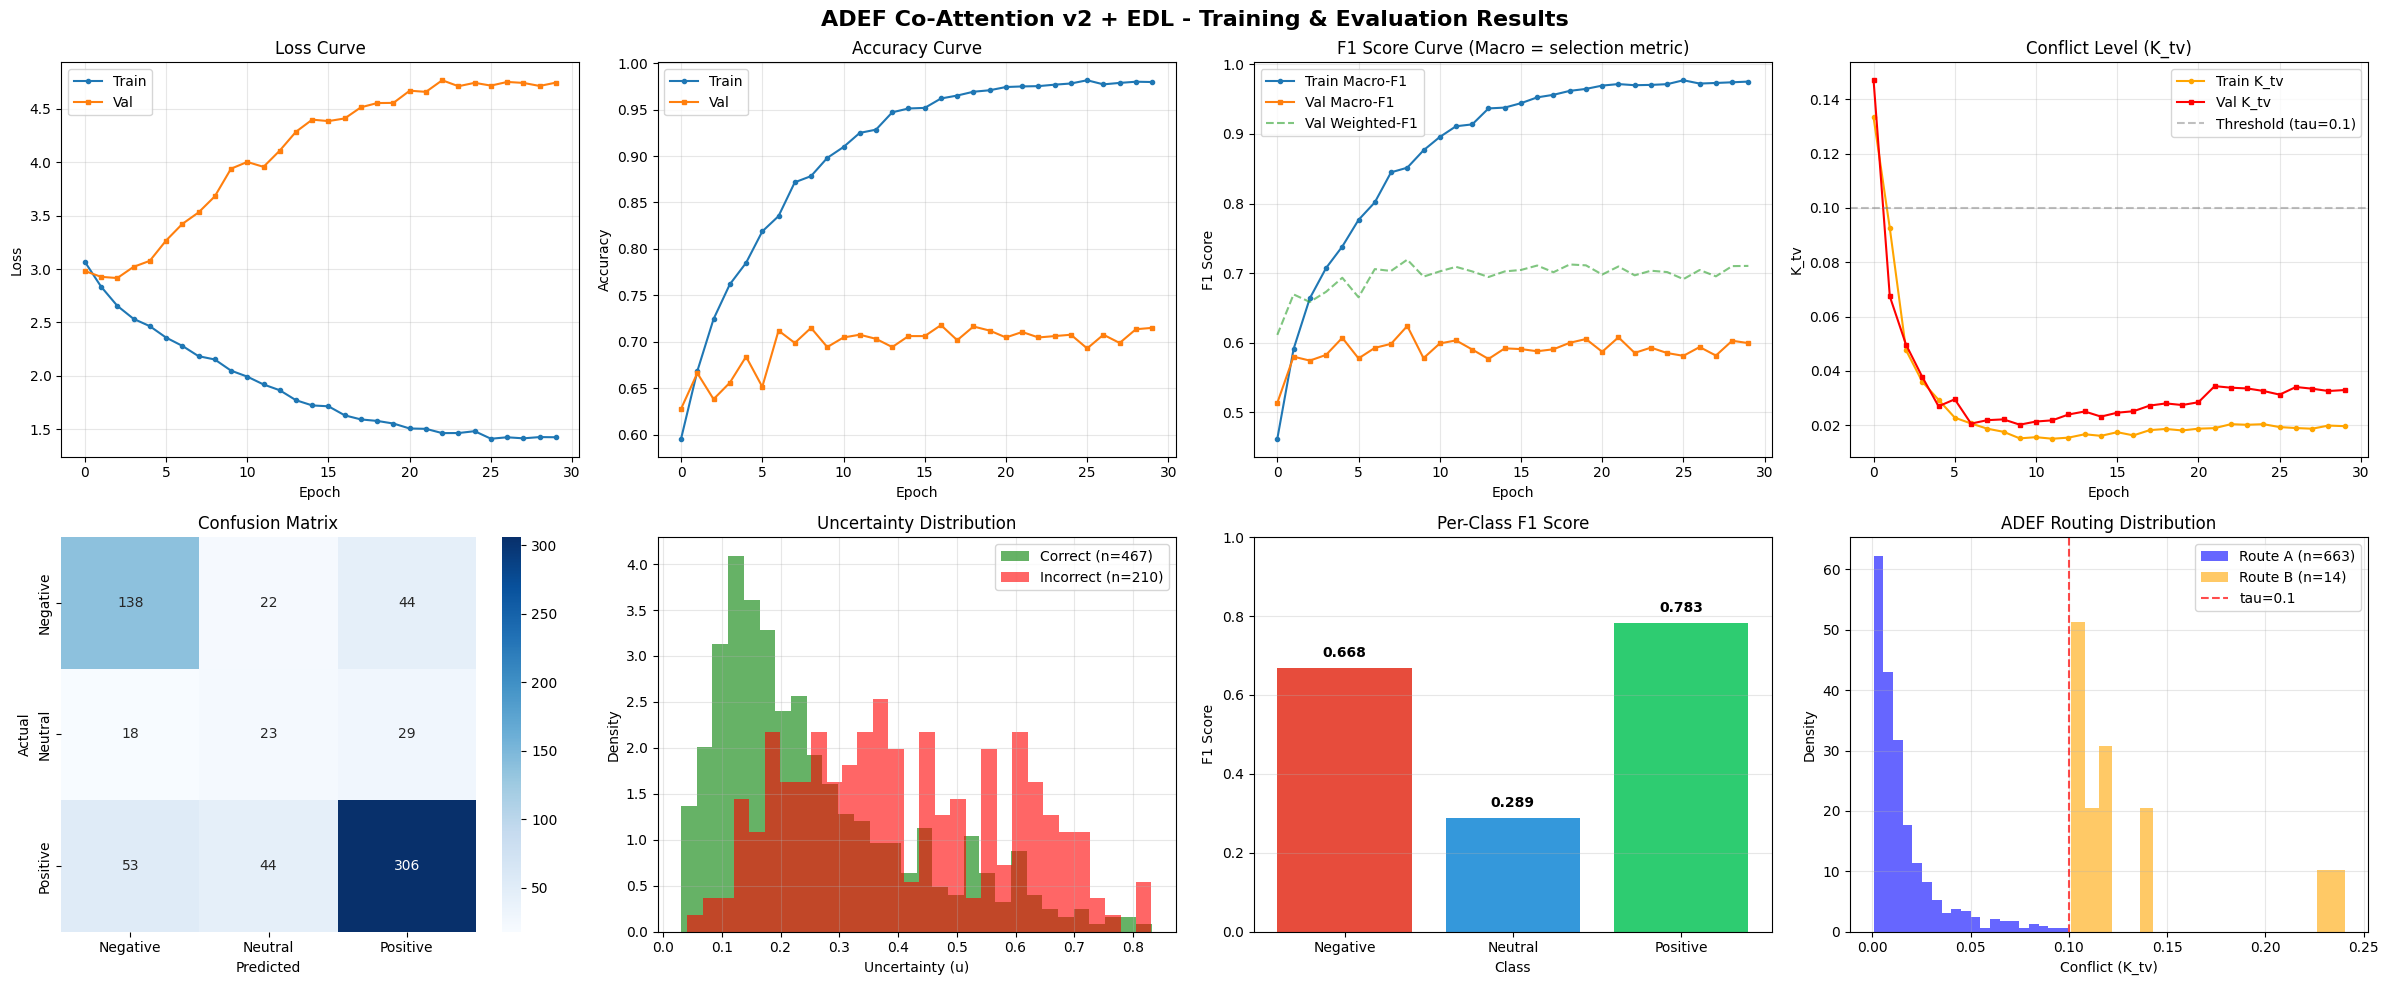

✅ Visualization complete.


In [14]:
# ============================================================
# VISUALIZATION
# ============================================================

fig, axes = plt.subplots(2, 4, figsize=(24, 10))
fig.suptitle("ADEF Co-Attention v2 + EDL - Training & Evaluation Results", fontsize=16, fontweight="bold")

# 1. Loss Curve
axes[0, 0].plot(history["train_loss"], label="Train", marker="o", markersize=3)
axes[0, 0].plot(history["val_loss"], label="Val", marker="s", markersize=3)
axes[0, 0].set_xlabel("Epoch"); axes[0, 0].set_ylabel("Loss")
axes[0, 0].set_title("Loss Curve"); axes[0, 0].legend(); axes[0, 0].grid(True, alpha=0.3)

# 2. Accuracy Curve
axes[0, 1].plot(history["train_acc"], label="Train", marker="o", markersize=3)
axes[0, 1].plot(history["val_acc"], label="Val", marker="s", markersize=3)
axes[0, 1].set_xlabel("Epoch"); axes[0, 1].set_ylabel("Accuracy")
axes[0, 1].set_title("Accuracy Curve"); axes[0, 1].legend(); axes[0, 1].grid(True, alpha=0.3)

# 3. F1 Curve (Macro = selection metric, Weighted for reference)
axes[0, 2].plot(history["train_f1_macro"], label="Train Macro-F1", marker="o", markersize=3)
axes[0, 2].plot(history["val_f1_macro"], label="Val Macro-F1", marker="s", markersize=3)
axes[0, 2].plot(history["val_f1"], label="Val Weighted-F1", linestyle="--", alpha=0.6)
axes[0, 2].set_xlabel("Epoch"); axes[0, 2].set_ylabel("F1 Score")
axes[0, 2].set_title("F1 Score Curve (Macro = selection metric)"); axes[0, 2].legend(); axes[0, 2].grid(True, alpha=0.3)

# 4. Conflict K_tv Curve (threshold line from CFG.TAU)
axes[0, 3].plot(history["train_conflict"], label="Train K_tv", marker="o", markersize=3, color="orange")
axes[0, 3].plot(history["val_conflict"], label="Val K_tv", marker="s", markersize=3, color="red")
axes[0, 3].axhline(y=CFG.TAU, color="gray", linestyle="--", alpha=0.5, label=f"Threshold (tau={CFG.TAU})")
axes[0, 3].set_xlabel("Epoch"); axes[0, 3].set_ylabel("K_tv")
axes[0, 3].set_title("Conflict Level (K_tv)"); axes[0, 3].legend(); axes[0, 3].grid(True, alpha=0.3)

# 5. Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Negative", "Neutral", "Positive"],
            yticklabels=["Negative", "Neutral", "Positive"],
            ax=axes[1, 0])
axes[1, 0].set_xlabel("Predicted"); axes[1, 0].set_ylabel("Actual")
axes[1, 0].set_title("Confusion Matrix")

# 6. Uncertainty Distribution (Correct vs Incorrect)
correct_mask = all_preds == all_labels
axes[1, 1].hist(all_uncertainties[correct_mask], bins=30, alpha=0.6,
                label=f"Correct (n={correct_mask.sum()})", color="green", density=True)
if (~correct_mask).sum() > 0:
    axes[1, 1].hist(all_uncertainties[~correct_mask], bins=30, alpha=0.6,
                    label=f"Incorrect (n={(~correct_mask).sum()})", color="red", density=True)
axes[1, 1].set_xlabel("Uncertainty (u)"); axes[1, 1].set_ylabel("Density")
axes[1, 1].set_title("Uncertainty Distribution"); axes[1, 1].legend(); axes[1, 1].grid(True, alpha=0.3)

# 7. Per-Class F1 Scores (neutral must be > 0)
class_names = ["Negative", "Neutral", "Positive"]
bars = axes[1, 2].bar(class_names, f1_per_class, color=["#e74c3c", "#3498db", "#2ecc71"])
axes[1, 2].set_xlabel("Class"); axes[1, 2].set_ylabel("F1 Score")
axes[1, 2].set_title("Per-Class F1 Score"); axes[1, 2].set_ylim(0, 1)
for bar, val in zip(bars, f1_per_class):
    axes[1, 2].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
                    f"{val:.3f}", ha="center", va="bottom", fontweight="bold")
axes[1, 2].grid(True, alpha=0.3, axis="y")

# 8. Conflict Distribution & Route Breakdown (split at CFG.TAU)
axes[1, 3].hist(all_conflicts[all_conflicts <= CFG.TAU], bins=20, alpha=0.6,
                label=f"Route A (n={(all_conflicts <= CFG.TAU).sum()})", color="blue", density=True)
axes[1, 3].hist(all_conflicts[all_conflicts > CFG.TAU], bins=20, alpha=0.6,
                label=f"Route B (n={(all_conflicts > CFG.TAU).sum()})", color="orange", density=True)
axes[1, 3].axvline(x=CFG.TAU, color="red", linestyle="--", alpha=0.7, label=f"tau={CFG.TAU}")
axes[1, 3].set_xlabel("Conflict (K_tv)"); axes[1, 3].set_ylabel("Density")
axes[1, 3].set_title("ADEF Routing Distribution"); axes[1, 3].legend(); axes[1, 3].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("adef_co_attention_results.png", dpi=150, bbox_inches="tight")
plt.show()

print("\u2705 Visualization complete.")